In [37]:
# import zipfile as zip
# file=zip.ZipFile('/content/playground-series-s6e9.zip','r')
# file.extractall()
# file.close()

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import numpy as np


In [39]:
df=pd.read_csv('train.csv')
df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [40]:
df.shape

(668665, 15)

In [41]:
df['Will_Buy_EV'].value_counts(normalize=True)

Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64

In [42]:
df.drop('id',axis=1,inplace=True)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Age                          668665 non-null  int64  
 1   Annual_Income_USD            668665 non-null  float64
 2   Daily_Commute_km             668665 non-null  float64
 3   Number_of_Cars_Owned         668665 non-null  int64  
 4   Charging_Stations_Near_Home  668665 non-null  int64  
 5   Charging_Stations_Near_Work  668665 non-null  int64  
 6   Environmental_Concern_Level  668665 non-null  float64
 7   Gender                       668665 non-null  object 
 8   City_Type                    668665 non-null  object 
 9   Current_Car_Type             668665 non-null  object 
 10  Home_Charging_Possible       668665 non-null  object 
 11  Subsidy_Available            668665 non-null  object 
 12  Range_Anxiety_Level          668665 non-null  object 
 13 

In [44]:
df.describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [45]:
df.isnull().sum()

Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

In [46]:
pd.crosstab(
    df["Current_Car_Type"],
    df["Will_Buy_EV"],
    normalize="index"
) * 100


Will_Buy_EV,No,Yes
Current_Car_Type,,
Hatchback,82.570055,17.429945
SUV,81.904723,18.095277
Sedan,82.803278,17.196722
Truck,84.358667,15.641333


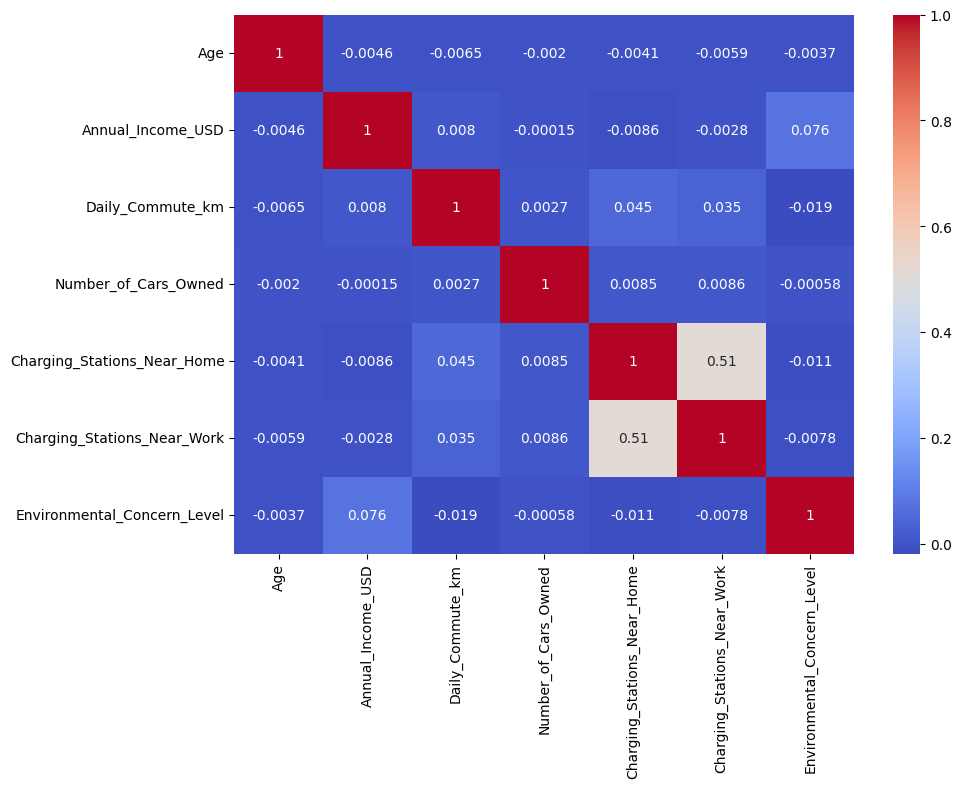

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()


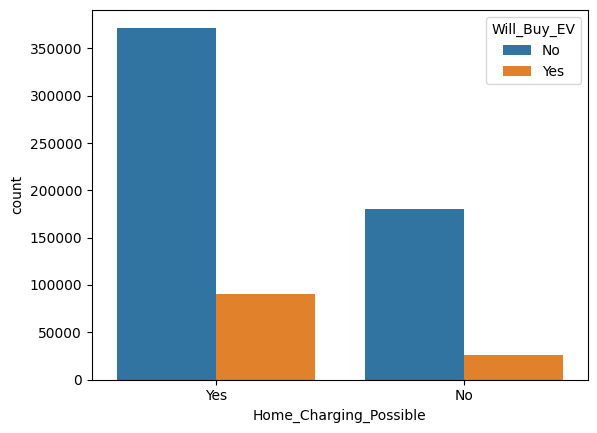

In [48]:
sns.countplot(
    data=df,
    x="Home_Charging_Possible",
    hue="Will_Buy_EV"
)
plt.show()


In [49]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["Subsidy_Available"],
    df["Will_Buy_EV"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)


Chi-square: 78382.49954402247
p-value: 0.0


In [50]:
numeric_cols
categorical_cols = df.select_dtypes(include=["object"]).columns

In [51]:
numeric_cols

Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level'],
      dtype='object')

In [52]:
categorical_cols

Index(['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

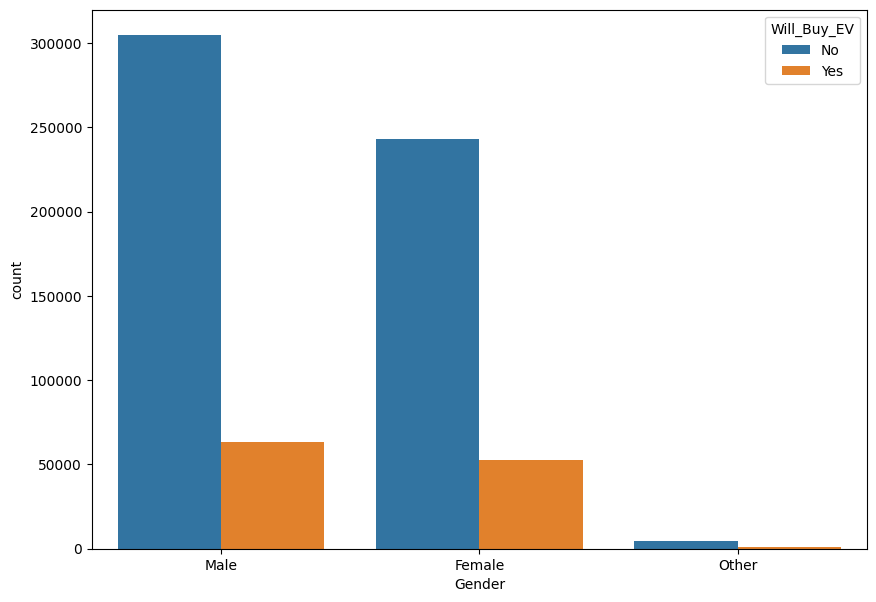

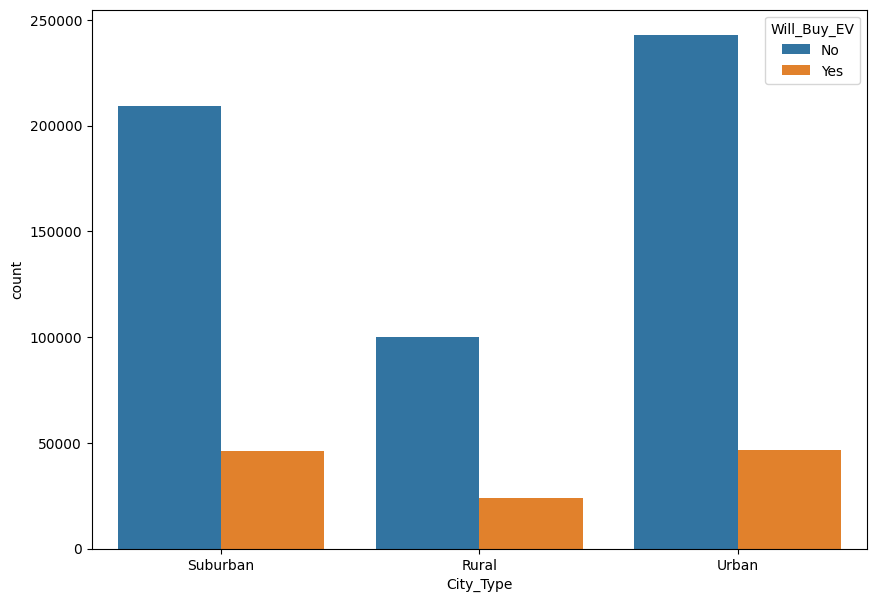

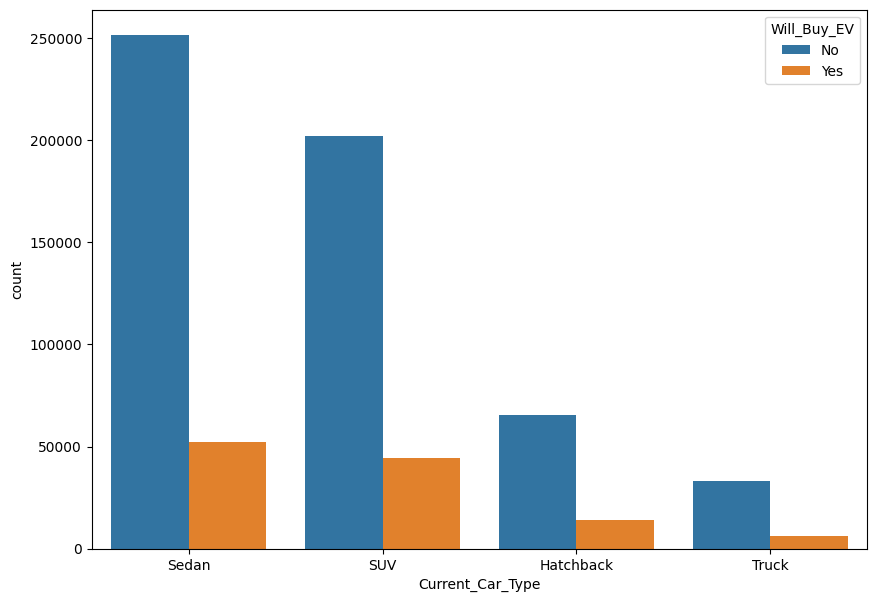

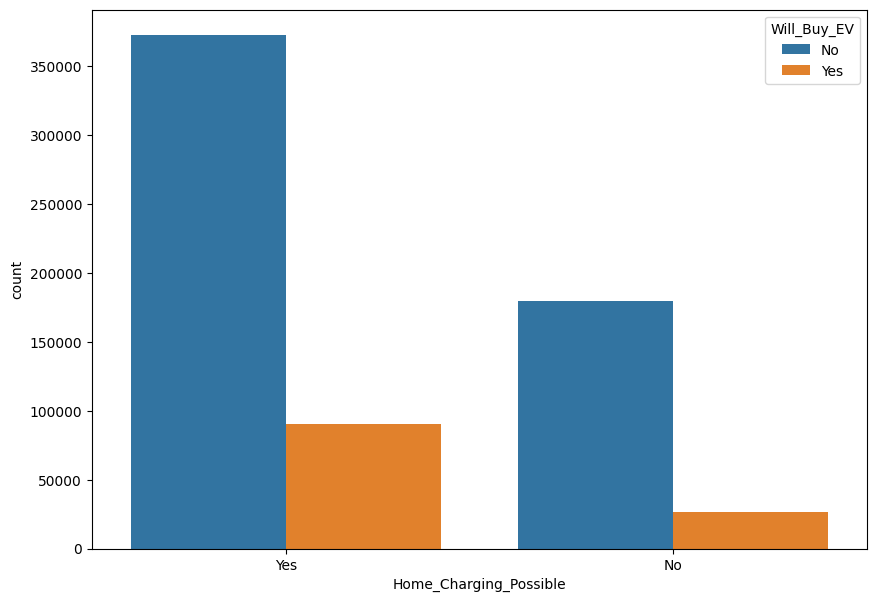

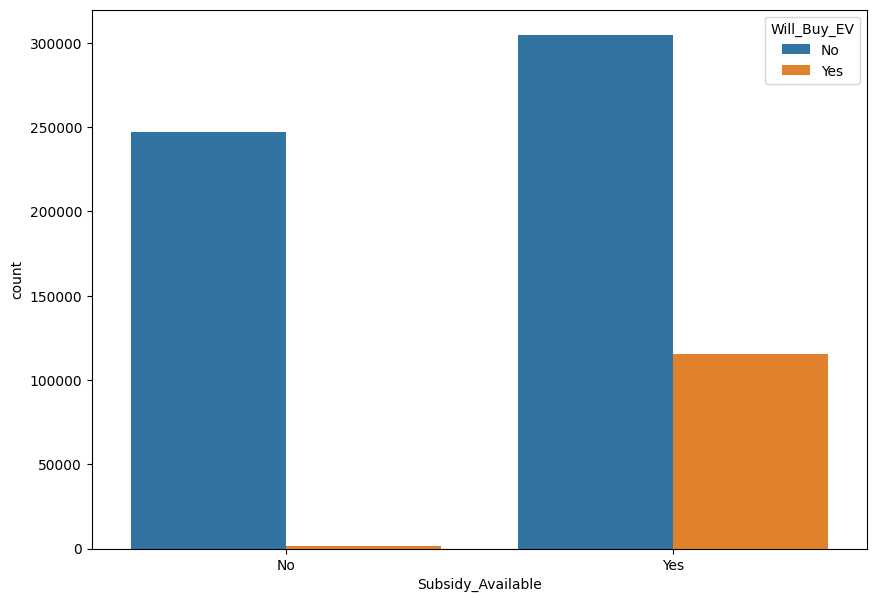

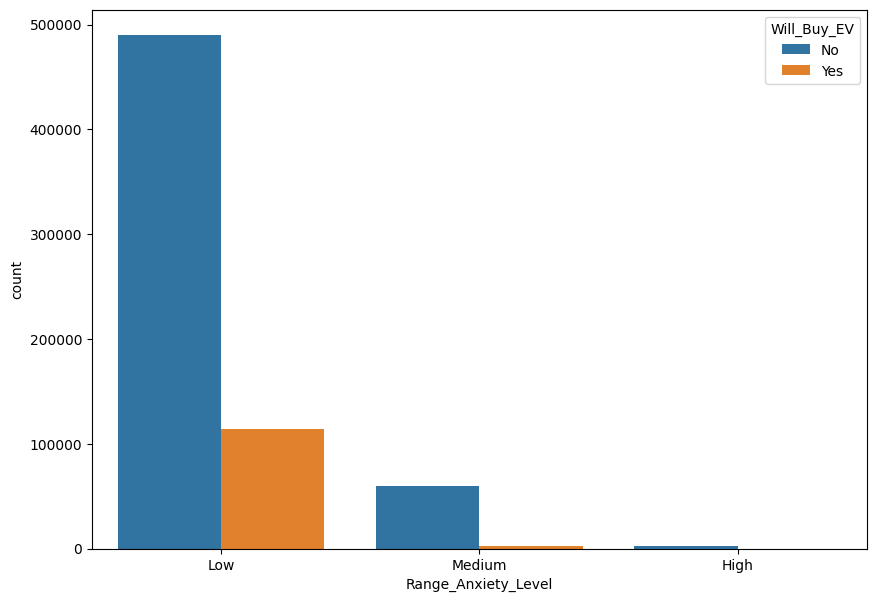

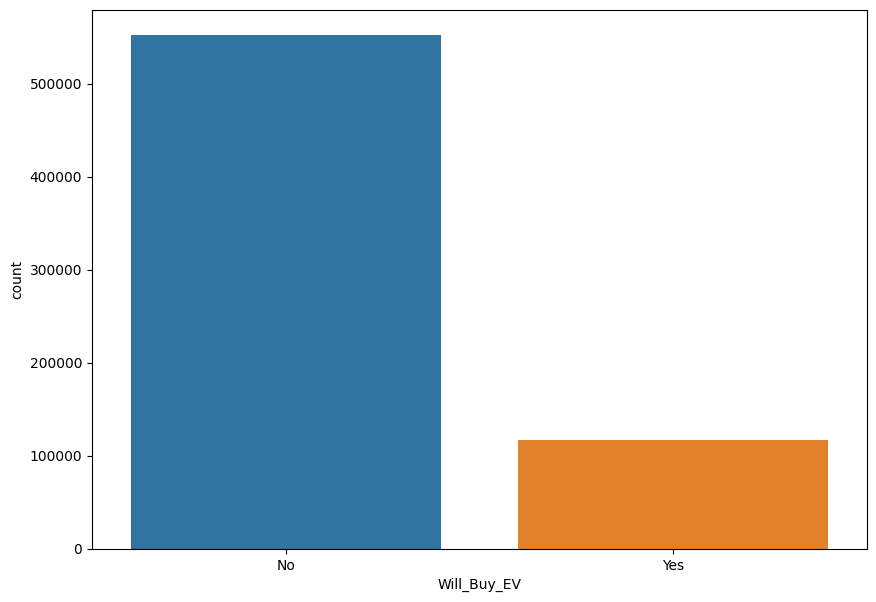

In [53]:
for col in categorical_cols:
    plt.figure(figsize=(10, 7))
    sns.countplot(
        data=df,
        x=col,
        hue="Will_Buy_EV"
    )
    plt.show()

Gender


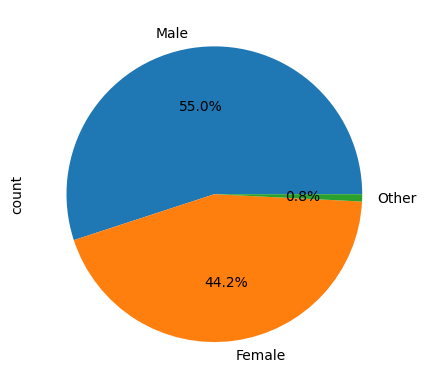

City_Type


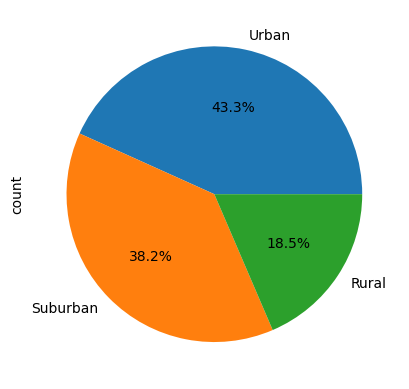

Current_Car_Type


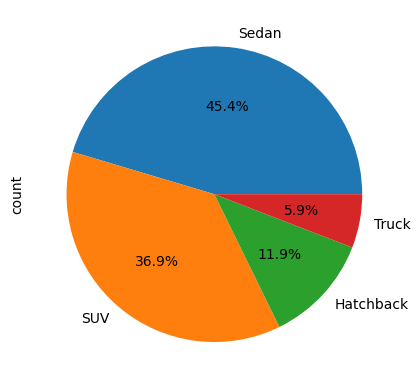

Home_Charging_Possible


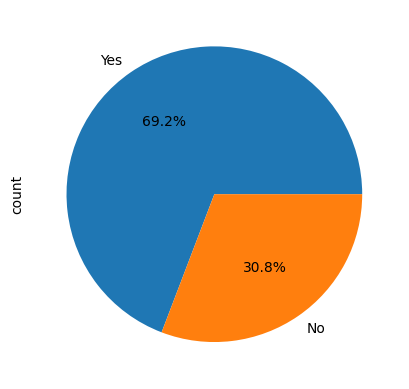

Subsidy_Available


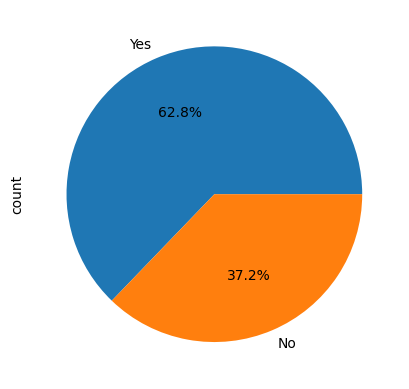

Range_Anxiety_Level


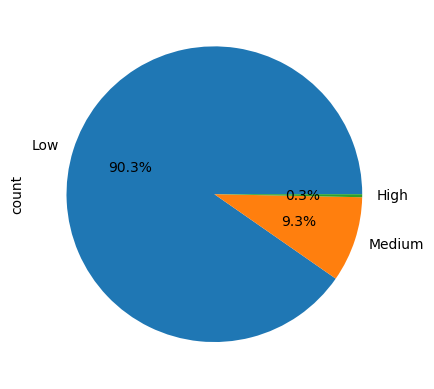

Will_Buy_EV


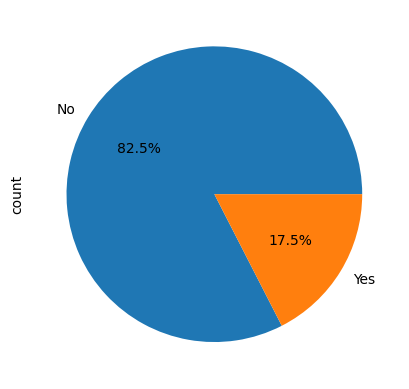

In [54]:
for col in categorical_cols:
  print(f"{col}")
  df[col].value_counts().plot.pie(autopct='%1.1f%%')
  plt.show()

In [55]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level"
]

numeric_cols = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level"
]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numeric_cols)
])


In [56]:
preprocessor

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [57]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df["Will_Buy_EV"])


In [58]:
df.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [59]:
df.shape

(668665, 14)

In [60]:
all_cols = numeric_cols + list(categorical_cols)

new_df = df[all_cols]
print(new_df.shape)
print(new_df.columns)
new_df.head()


(668665, 13)
Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'Gender', 'City_Type',
       'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available',
       'Range_Anxiety_Level'],
      dtype='object')


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low


In [61]:
new_df

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium
668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low
668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low
668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low


In [62]:
categorical_cols = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level" # Added this categorical feature
]


In [63]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

encoded = encoder.fit_transform(new_df[categorical_cols])


In [64]:
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=new_df.index
)


In [65]:
final_df = pd.concat(
    [
        new_df[numeric_cols],
        encoded_df
    ],
    axis=1
)


In [66]:
final_df

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender_Male,Gender_Other,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Home_Charging_Possible_Yes,Subsidy_Available_Yes,Range_Anxiety_Level_Low,Range_Anxiety_Level_Medium
0,66,92887.0,23.4,2,3,7,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,38,30000.0,5.0,1,2,2,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,26,94389.0,36.8,1,8,15,5.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,66,73580.0,23.7,2,6,9,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,54,57898.0,50.8,1,2,3,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
668661,32,129990.0,5.0,2,5,4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
668662,64,121791.0,24.2,1,5,6,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
668663,51,115923.0,43.7,2,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0


In [67]:
numerical_df = df[numeric_cols]

final_df = pd.concat(
    [numerical_df, encoded_df],
    axis=1
)


In [68]:
final_df.columns

Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'Gender_Male', 'Gender_Other',
       'City_Type_Suburban', 'City_Type_Urban', 'Current_Car_Type_SUV',
       'Current_Car_Type_Sedan', 'Current_Car_Type_Truck',
       'Home_Charging_Possible_Yes', 'Subsidy_Available_Yes',
       'Range_Anxiety_Level_Low', 'Range_Anxiety_Level_Medium'],
      dtype='object')

In [69]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
df['Will_Buy_EV']=label.fit_transform(df['Will_Buy_EV'])

In [70]:
final_df['Will_Buy_EV']=df['Will_Buy_EV']

In [71]:
from sklearn.model_selection import train_test_split
x=final_df.drop('Will_Buy_EV',axis=1)
y=final_df['Will_Buy_EV']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42,stratify=y)

In [72]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    criterion="gini",
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
y_prob = rf.predict_proba(x_test)[:, 1]


In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy : 0.8970452279525061
Precision: 0.7328172372177906
Recall   : 0.6460284920985028
F1 Score : 0.6866914908288512
ROC-AUC  : 0.9391099984277764

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94    182123
           1       0.73      0.65      0.69     38537

    accuracy                           0.90    220660
   macro avg       0.83      0.80      0.81    220660
weighted avg       0.89      0.90      0.89    220660



In [74]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(x_train, y_train)

y_pred_balanced = rf_balanced.predict(x_test)


In [75]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_balanced))

y_prob_balanced = rf_balanced.predict_proba(x_test)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_balanced)
)


              precision    recall  f1-score   support

           0       0.98      0.85      0.91    182123
           1       0.56      0.90      0.69     38537

    accuracy                           0.86    220660
   macro avg       0.77      0.87      0.80    220660
weighted avg       0.90      0.86      0.87    220660

ROC-AUC: 0.9389694073259457


In [76]:
sample_submission = pd.read_csv("sample_submission.csv")

In [77]:
sample_submission.head()

,id,Will_Buy_EV
0,668665,0.174645
1,668666,0.174645
2,668667,0.174645
3,668668,0.174645
4,668669,0.174645


In [78]:
test=pd.read_csv('test.csv')

In [79]:
test.shape

(286571, 14)

In [80]:
test.columns

Index(['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level'],
      dtype='object')

In [81]:
categorical = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level"
]
numeric = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level"
]

In [82]:
encode=encoder.fit_transform(test[categorical])

In [83]:
encode_df=pd.DataFrame(
    encode,
    columns=encoder.get_feature_names_out(categorical),
    index=test.index # Corrected index
)

In [84]:
test=pd.concat(
    [test[numeric],encode_df],
    axis=1
)

In [85]:
test.shape

(286571, 18)

In [86]:
test.columns

Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'Gender_Male', 'Gender_Other',
       'City_Type_Suburban', 'City_Type_Urban', 'Current_Car_Type_SUV',
       'Current_Car_Type_Sedan', 'Current_Car_Type_Truck',
       'Home_Charging_Possible_Yes', 'Subsidy_Available_Yes',
       'Range_Anxiety_Level_Low', 'Range_Anxiety_Level_Medium'],
      dtype='object')

In [87]:
# Reload test data to ensure a clean start for preprocessing
test_raw = pd.read_csv('test.csv')

# Keep the ID column for submission
test_ids = test_raw['id']

# Define categorical and numerical columns for test data, consistent with training
categorical_test_cols = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level"
]
numeric_test_cols = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level"
]

# Apply the already fitted OneHotEncoder to categorical features
encoded_test_features = encoder.transform(test_raw[categorical_test_cols])

# Create a DataFrame from the encoded features
encoded_test_df = pd.DataFrame(
    encoded_test_features,
    columns=encoder.get_feature_names_out(categorical_test_cols),
    index=test_raw.index
)

# Concatenate numerical and encoded categorical features for the test set
X_test_processed = pd.concat(
    [test_raw[numeric_test_cols], encoded_test_df],
    axis=1
)

# Ensure the columns in X_test_processed match x_train.columns
# This step handles any potential column order or missing column issues
missing_cols = set(x_train.columns) - set(X_test_processed.columns)
for c in missing_cols:
    X_test_processed[c] = 0 # Add missing columns with default value 0 (for one-hot encoded features)

X_test_final = X_test_processed[x_train.columns] # Ensure column order is the same

print("Shape of processed test data:", X_test_final.shape)
print("Columns of processed test data:\n", X_test_final.columns)


Shape of processed test data: (286571, 18)
Columns of processed test data:
 Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'Gender_Male', 'Gender_Other',
       'City_Type_Suburban', 'City_Type_Urban', 'Current_Car_Type_SUV',
       'Current_Car_Type_Sedan', 'Current_Car_Type_Truck',
       'Home_Charging_Possible_Yes', 'Subsidy_Available_Yes',
       'Range_Anxiety_Level_Low', 'Range_Anxiety_Level_Medium'],
      dtype='object')


In [88]:
# Generate predictions using the balanced Random Forest model
predictions = rf_balanced.predict(X_test_final)

# Create submission file
submission = pd.DataFrame({
    "id": test_ids,
    "Will_Buy_EV": predictions
})

# # Map numerical predictions back to 'Yes'/'No' if LabelEncoder was used for 'Will_Buy_EV'
# # Assuming 'y' was encoded where 0='No' and 1='Yes' (check `le.classes_`)
# if 'le' in globals() and hasattr(le, 'classes_'):
#     submission['Will_Buy_EV'] = le.inverse_transform(submission['Will_Buy_EV'])

# Save submission
submission.to_csv("submission.csv", index=False)

print(submission.head())
print("Submission shape:", submission.shape)


       id  Will_Buy_EV
0  668665            0
1  668666            0
2  668667            0
3  668668            0
4  668669            0
Submission shape: (286571, 2)


In [89]:
import joblib

# Save the trained model
joblib.dump(rf_balanced, 'random_forest_balanced_model.joblib')

print("Trained model saved as 'random_forest_balanced_model.joblib'")

Trained model saved as 'random_forest_balanced_model.joblib'


In [91]:
submission=pd.read_csv('submission.csv')
submission.head(15)

,id,Will_Buy_EV
0,668665,0
1,668666,0
2,668667,0
3,668668,0
4,668669,0
5,668670,0
6,668671,1
7,668672,0
8,668673,1
9,668674,0


In [92]:
sample_submission.head(10)

,id,Will_Buy_EV
0,668665,0.174645
1,668666,0.174645
2,668667,0.174645
3,668668,0.174645
4,668669,0.174645
5,668670,0.174645
6,668671,0.174645
7,668672,0.174645
8,668673,0.174645
9,668674,0.174645
